# 03 — Content-Based Recommender
**Group 12 | Inside Airbnb Madrid — Apartment Recommendation System**

**Contributor**:

Content-based filtering recommends listings similar to a traveler's stated preferences or past bookings, using listing features alone — no interaction data needed. This makes it the most **cold-start robust** approach.

This notebook implements:
1. Feature engineering: 50+ dimensional listing feature vector
2. TF-IDF on listing descriptions and amenity strings
3. Cosine similarity-based content recommender
4. **Interactive query interface** — traveler specifies budget, neighbourhood, amenities → ranked results
5. Evaluation: Precision@10, Recall@10, NDCG@10, Coverage

In [1]:
# ── Google Colab: mount Drive and set data paths ──────────────────────────────
# Run this cell first every time you open the notebook in Colab.
# Your data files should be at:
#   My Drive/recommender_project/data/listings.csv.gz
#   My Drive/recommender_project/data/reviews.csv
#
# If running LOCALLY (not Colab), skip this cell — paths are set below.

import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive/recommender_project/data'
    print('✓ Google Drive mounted')
except ImportError:
    # Running locally — data folder is next to the notebooks
    DATA_DIR = 'data'
    print('✓ Running locally — using data/ folder')

LISTINGS_PATH = os.path.join(DATA_DIR, 'listings.csv.gz')
REVIEWS_PATH  = os.path.join(DATA_DIR, 'reviews.csv')
print(f'Listings : {LISTINGS_PATH}')
print(f'Reviews  : {REVIEWS_PATH}')


Mounted at /content/drive
✓ Google Drive mounted
Listings : /content/drive/MyDrive/recommender_project/data/listings.csv.gz
Reviews  : /content/drive/MyDrive/recommender_project/data/reviews.csv


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import warnings, os, ast, re

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
print('✓ Libraries loaded')

✓ Libraries loaded


In [3]:
# ── Load data ─────────────────────────────────────────────────────────────────
listings = pd.read_csv(LISTINGS_PATH, low_memory=False)
reviews  = pd.read_csv(REVIEWS_PATH,     low_memory=False)
reviews['date'] = pd.to_datetime(reviews['date'])

# ── Repeat core cleaning (mirrors notebook 01) ────────────────────────────────
listings['price_clean'] = (
    listings['price'].astype(str).str.replace(r'[$,]', '', regex=True)
    .replace('', np.nan).astype(float)
)
listings = listings[listings['price_clean'].isna() | (listings['price_clean'] <= 2000)].copy()

listings['review_scores_rating'] = pd.to_numeric(listings['review_scores_rating'], errors='coerce')
listings['review_scores_rating'] = listings.groupby('neighbourhood_cleansed')[
    'review_scores_rating'
].transform(lambda x: x.fillna(x.mean())).fillna(listings['review_scores_rating'].mean())

for col in ['review_scores_cleanliness','review_scores_location','review_scores_value',
            'review_scores_checkin','review_scores_communication']:
    listings[col] = pd.to_numeric(listings[col], errors='coerce').fillna(4.5)

listings['is_superhost']    = (listings['host_is_superhost'] == 't').astype(int)
listings['is_instant_book'] = (listings['instant_bookable']  == 't').astype(int)
listings['host_response_rate'] = pd.to_numeric(
    listings['host_response_rate'].astype(str).str.replace('%',''), errors='coerce'
).fillna(80) / 100
listings['host_acceptance_rate'] = pd.to_numeric(
    listings['host_acceptance_rate'].astype(str).str.replace('%',''), errors='coerce'
).fillna(80) / 100

for col in ['accommodates','bedrooms','beds','number_of_reviews',
            'host_listings_count','minimum_nights']:
    listings[col] = pd.to_numeric(listings[col], errors='coerce')

listings['number_of_reviews'] = listings['number_of_reviews'].fillna(0)
listings['accommodates']      = listings['accommodates'].fillna(2)
listings['minimum_nights']    = listings['minimum_nights'].fillna(1).clip(1,365)
listings['bedrooms']          = listings['bedrooms'].fillna(1)
listings['beds']              = listings['beds'].fillna(1)
listings['host_listings_count'] = listings['host_listings_count'].fillna(1)

listings['host_since'] = pd.to_datetime(listings['host_since'], errors='coerce')
listings['host_years'] = (
    (pd.Timestamp('2025-01-01') - listings['host_since']).dt.days / 365.25
).clip(0, 20).fillna(3)

# Bayesian average (for ranking within results)
C, m = listings['review_scores_rating'].mean(), 50
listings['bayesian_avg'] = (
    (listings['number_of_reviews'] / (listings['number_of_reviews'] + m)) * listings['review_scores_rating']
    + (m / (listings['number_of_reviews'] + m)) * C
)

# Amenity flags
amenity_map = {
    'wifi'     : r'wifi|wi-fi',
    'kitchen'  : r'kitchen',
    'ac'       : r'air conditioning|air-conditioning',
    'heating'  : r'heating',
    'washer'   : r'washer|washing machine',
    'tv'       : r'\btv\b|television',
    'parking'  : r'parking|garage',
    'elevator' : r'elevator|lift',
    'gym'      : r'\bgym\b|fitness center',
    'pets'     : r'pets allowed',
}
amenities_str = listings['amenities'].fillna('').str.lower()
for name, pat in amenity_map.items():
    listings[f'am_{name}'] = amenities_str.str.contains(pat, regex=True).astype(int)

print(f'Data loaded and cleaned: {len(listings):,} listings')

Data loaded and cleaned: 24,958 listings


## 1. Feature Engineering

In [4]:
# ── Build numerical feature matrix ───────────────────────────────────────────
# Features grouped by category:

# 1. Location: neighbourhood one-hot (top 30 by frequency, rest → 'Other')
top_hoods = listings['neighbourhood_cleansed'].value_counts().head(30).index
listings['hood_grouped'] = listings['neighbourhood_cleansed'].where(
    listings['neighbourhood_cleansed'].isin(top_hoods), 'Other'
)
hood_ohe = pd.get_dummies(listings['hood_grouped'], prefix='h').astype(float)

# 2. Room type one-hot
room_ohe = pd.get_dummies(listings['room_type'].fillna('Entire home/apt'), prefix='r').astype(float)

# 3. Price features (log-normalised)
price_med = listings['price_clean'].median()
listings['log_price'] = np.log1p(listings['price_clean'].fillna(price_med))

# Price tier: 0=budget(<€60), 1=mid(€60-150), 2=premium(>€150)
listings['price_tier'] = pd.cut(
    listings['price_clean'].fillna(price_med),
    bins=[0, 60, 150, 10000], labels=[0, 1, 2]
).astype(float)

# 4. Capacity features
listings['log_accommodates'] = np.log1p(listings['accommodates'])
listings['log_bedrooms']     = np.log1p(listings['bedrooms'].clip(0,10))

# 5. Host quality (normalised 0-1)
scaler = MinMaxScaler()
host_cols = ['host_response_rate','host_acceptance_rate','host_years','is_superhost']
host_scaled = scaler.fit_transform(
    listings[host_cols].fillna(0)
)
host_df = pd.DataFrame(host_scaled, columns=[f'host_{c}' for c in host_cols],
                        index=listings.index)

# 6. Review score sub-dimensions (normalised 0-1, scaled from 1-5 → 0-1)
score_cols = ['review_scores_rating','review_scores_cleanliness','review_scores_location',
              'review_scores_value','review_scores_checkin','review_scores_communication']
scores_norm = (listings[score_cols].fillna(4.5) - 1) / 4  # 1-5 → 0-1
scores_norm.columns = [f'sc_{c.replace("review_scores_","")}' for c in score_cols]

# 7. Amenity flags (already binary 0/1)
amenity_cols = [f'am_{k}' for k in amenity_map.keys()]
amenity_df   = listings[amenity_cols].fillna(0)

# 8. Booking policy
listings['log_min_nights'] = np.log1p(listings['minimum_nights'])
policy_df = listings[['is_instant_book','log_min_nights']].fillna(0)

# ── Concatenate all features ──────────────────────────────────────────────────
feature_blocks = [
    hood_ohe.reset_index(drop=True),
    room_ohe.reset_index(drop=True),
    listings[['log_price','price_tier','log_accommodates','log_bedrooms']].reset_index(drop=True),
    host_df.reset_index(drop=True),
    scores_norm.reset_index(drop=True),
    amenity_df.reset_index(drop=True),
    policy_df.reset_index(drop=True),
]
feature_matrix_raw = pd.concat(feature_blocks, axis=1).fillna(0)

# L2-normalise each listing's feature vector
feature_matrix = normalize(feature_matrix_raw.values.astype(float), norm='l2')

# Index by listing id
listing_ids = listings['id'].values
feat_id_to_pos = {lid: i for i, lid in enumerate(listing_ids)}
feature_df = pd.DataFrame(feature_matrix, index=listings['id'].values)

print(f'Feature matrix: {feature_matrix.shape}')
print(f'  - Neighbourhood OHE : {hood_ohe.shape[1]} dims')
print(f'  - Room type OHE     : {room_ohe.shape[1]} dims')
print(f'  - Price features    : 4 dims')
print(f'  - Host quality      : {len(host_cols)} dims')
print(f'  - Review scores     : {len(score_cols)} dims')
print(f'  - Amenity flags     : {len(amenity_cols)} dims')
print(f'  - Booking policy    : 2 dims')
print(f'  Total               : {feature_matrix.shape[1]} dimensions')

Feature matrix: (24958, 61)
  - Neighbourhood OHE : 31 dims
  - Room type OHE     : 4 dims
  - Price features    : 4 dims
  - Host quality      : 4 dims
  - Review scores     : 6 dims
  - Amenity flags     : 10 dims
  - Booking policy    : 2 dims
  Total               : 61 dimensions


In [5]:
# ── TF-IDF on listing descriptions + amenity text ────────────────────────────
# Combine description, neighborhood_overview, and amenities into one text field
listings['description_text'] = (
    listings['description'].fillna('') + ' ' +
    listings['neighborhood_overview'].fillna('') + ' ' +
    listings['amenities'].fillna('').str.replace(r'[\[\]"{}]', ' ', regex=True)
).str.lower().str.replace(r'[^a-záéíóúüñ0-9 ]', ' ', regex=True)

tfidf = TfidfVectorizer(
    max_features=150,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=10,
    max_df=0.85
)
desc_matrix = tfidf.fit_transform(listings['description_text']).toarray()
desc_df = pd.DataFrame(desc_matrix, index=listings['id'].values)

print(f'TF-IDF matrix: {desc_matrix.shape}')
top_terms = tfidf.get_feature_names_out()[:20]
print(f'Top 20 TF-IDF terms: {list(top_terms)}')

TF-IDF matrix: (24958, 150)
Top 20 TF-IDF terms: ['air', 'air conditioning', 'alarm', 'allowed', 'allowed hot', 'apartment', 'area', 'available', 'away', 'balcony', 'basics', 'basics shampoo', 'bathroom', 'bed', 'bed linens', 'bedroom', 'blankets', 'body', 'body soap', 'br']


## 2. Content-Based Similarity & Recommendations

In [6]:
# ── Content-based recommendation function ────────────────────────────────────
FEAT_WEIGHT = 0.65  # weight for structured features
DESC_WEIGHT = 0.35  # weight for TF-IDF description similarity

def recommend_similar_listing(listing_id, top_k=10, same_hood=False):
    """
    Find top_k listings most similar to listing_id
    using structured features + TF-IDF description.
    """
    if listing_id not in feature_df.index:
        print(f'Listing {listing_id} not in feature index.')
        return pd.DataFrame()

    # Structured feature similarity
    query_feat = feature_df.loc[listing_id].values.reshape(1, -1)
    feat_sims  = cosine_similarity(query_feat, feature_matrix)[0]

    # Description similarity
    if listing_id in desc_df.index:
        query_desc = desc_df.loc[listing_id].values.reshape(1, -1)
        desc_sims  = cosine_similarity(query_desc, desc_matrix)[0]
    else:
        desc_sims = feat_sims  # fallback

    combined = FEAT_WEIGHT * feat_sims + DESC_WEIGHT * desc_sims

    # Build result dataframe
    sim_series = pd.Series(combined, index=listings['id'].values)
    sim_series = sim_series.drop(listing_id, errors='ignore')

    top_ids = sim_series.nlargest(top_k * 3).index
    result  = listings[listings['id'].isin(top_ids)].copy()
    result['similarity'] = result['id'].map(sim_series.to_dict())

    if same_hood:
        query_hood = listings[listings['id']==listing_id]['neighbourhood_cleansed'].values[0]
        result = result[result['neighbourhood_cleansed'] == query_hood]

    return result.sort_values('similarity', ascending=False).head(top_k)[
        ['id','name','neighbourhood_cleansed','room_type','price_clean',
         'review_scores_rating','is_superhost','similarity']
    ]

# ── DEMO ─────────────────────────────────────────────────────────────────────
demo_id = listings.nlargest(1, 'number_of_reviews')['id'].values[0]
demo_name = listings[listings['id']==demo_id]['name'].values[0]
demo_hood = listings[listings['id']==demo_id]['neighbourhood_cleansed'].values[0]

print(f'Query: "{demo_name[:60]}" ({demo_hood})')
print('='*80)
print('Top 10 Content-Similar Listings:')
sim_results = recommend_similar_listing(demo_id, top_k=10)
for i, (_, row) in enumerate(sim_results.iterrows(), 1):
    sh = '⭐' if row['is_superhost'] else '  '
    print(f"  {i:2}. {sh} {row['name'][:50]:<50} | {row['neighbourhood_cleansed']:<15} | "
          f"€{row['price_clean']:<5.0f} | sim={row['similarity']:.3f}")

Query: "Apto Confort Cuenca" (Cuatro Caminos)
Top 10 Content-Similar Listings:
   1.    Apto tipo loft 4pax                                | Cuatro Caminos  | €167   | sim=0.942
   2.    Apartamento acogedor con encanto II                | Imperial        | €74    | sim=0.897
   3.    Piso Bernabéu                                      | Cuatro Caminos  | €119   | sim=0.891
   4.    Waou Justicia II - Alquiler Corta Duración         | Justicia        | €205   | sim=0.889
   5.    King sice                                          | Cuatro Caminos  | €133   | sim=0.889
   6.    Apartamento  Gran Via Centro Madrid                | Justicia        | €106   | sim=0.881
   7.    Luxury Design Apartment in Barrio las Letras A1 0i | Cortes          | €130   | sim=0.880
   8.    Elegant Central Stay in Madrid’s Best Location     | Embajadores     | €126   | sim=0.879
   9.    New & Modern 1BR in the Heart of Madrid            | Embajadores     | €143   | sim=0.879
  10.    Opera apartamento top

## 3. Interactive Query Interface (Cold-Start)

In [7]:
# ── Build a preference query vector from user inputs ─────────────────────────
def build_query_vector(
    budget_max=100,
    neighbourhood_pref=None,   # list of neighbourhood strings
    room_type_pref=None,       # e.g. 'Entire home/apt'
    group_size=2,
    must_haves=None,           # list of amenity keys: 'wifi','kitchen','ac', etc.
    prefer_superhost=False,
    prefer_instant_book=False,
    min_rating=4.0
):
    """
    Convert a traveler's stated preferences into a feature vector
    matching the 50-dimensional listing space.
    Returns filtered + ranked candidates.
    """
    candidates = listings.copy()

    # ── Hard filters ──────────────────────────────────────────────────────────
    # Price
    candidates = candidates[
        candidates['price_clean'].isna() | (candidates['price_clean'] <= budget_max)
    ]

    # Minimum rating
    candidates = candidates[candidates['review_scores_rating'] >= min_rating]

    # Room type
    if room_type_pref:
        candidates = candidates[candidates['room_type'] == room_type_pref]

    # Group size (must accommodate the group)
    candidates = candidates[candidates['accommodates'] >= group_size]

    # Neighbourhood preference (soft: just filter to those neighbourhoods)
    if neighbourhood_pref:
        candidates = candidates[
            candidates['neighbourhood_cleansed'].isin(neighbourhood_pref)
        ]

    # Must-have amenities
    if must_haves:
        for amenity in must_haves:
            col = f'am_{amenity}'
            if col in candidates.columns:
                candidates = candidates[candidates[col] == 1]

    if len(candidates) == 0:
        print('No listings match your criteria. Try relaxing some filters.')
        return pd.DataFrame()

    # ── Soft scoring (Bayesian avg + superhost + instant book bonuses) ─────────
    candidates = candidates.copy()
    candidates['query_score'] = candidates['bayesian_avg'].copy()

    if prefer_superhost:
        candidates['query_score'] += candidates['is_superhost'] * 0.05
    if prefer_instant_book:
        candidates['query_score'] += candidates['is_instant_book'] * 0.03

    # Price value bonus: reward listings well below budget
    price_filled = candidates['price_clean'].fillna(budget_max)
    candidates['query_score'] += (1 - price_filled / budget_max) * 0.03

    return candidates.sort_values('query_score', ascending=False)


# Emoji labels for each amenity key
AMENITY_TAGS = {
    'wifi'    : '📶 WiFi',
    'kitchen' : '🍳 Kitchen',
    'ac'      : '❄️ AC',
    'heating' : '🔥 Heating',
    'washer'  : '🫧 Washer',
    'tv'      : '📺 TV',
    'parking' : '🚗 Parking',
    'elevator': '🛗 Elevator',
    'gym'     : '🏋️ Gym',
    'pets'    : '🐾 Pets OK',
}

def display_recommendations(df, top_k=10, requested_amenities=None):
    """
    Pretty-print recommendation results.
    Only shows amenity tags for amenities that were actually requested,
    so tags carry real information rather than echoing near-universal features.
    """
    if df.empty:
        return
    top = df.head(top_k)
    for i, (_, row) in enumerate(top.iterrows(), 1):
        tags = []
        if row.get('is_superhost', 0):                  tags.append('⭐ Superhost')
        if row.get('review_scores_rating', 0) >= 4.8:   tags.append('🏆 Top rated')
        if row.get('is_instant_book', 0):               tags.append('⚡ Instant book')

        # Only show amenity tags for what the user asked for
        if requested_amenities:
            for am in requested_amenities:
                if row.get(f'am_{am}', 0):
                    tags.append(AMENITY_TAGS.get(am, am))

        price_str  = f"€{row['price_clean']:.0f}" if not pd.isna(row.get('price_clean')) else 'N/A'
        rating_str = f"{row.get('review_scores_rating', 0):.2f}"

        print(f"  {i:2}. {row['name'][:50]:<50}")
        print(f"      📍 {row['neighbourhood_cleansed']:<18} | 🏠 {row['room_type']:<22} | "
              f"{price_str}/night | ★ {rating_str}")
        if tags:
            print(f"      {' · '.join(tags)}")
        print()


# ══════════════════════════════════════════════════════════════════════════════
# DEMO 1: Weekend couple trip — central, up to €120, need WiFi + kitchen
# ══════════════════════════════════════════════════════════════════════════════
print('='*70)
print('DEMO 1: Weekend couple city break')
print('Budget: ≤€120 | Neighbourhoods: Embajadores, Sol, Universidad')
print('Room: Entire apt | Group: 2 | Must-have: WiFi + Kitchen | Superhost preferred')
print('='*70)

recs1 = build_query_vector(
    budget_max=120,
    neighbourhood_pref=['Embajadores','Sol','Universidad','Justicia','Cortes'],
    room_type_pref='Entire home/apt',
    group_size=2,
    must_haves=['wifi','kitchen'],
    prefer_superhost=True
)
display_recommendations(recs1, top_k=5, requested_amenities=['wifi','kitchen'])

DEMO 1: Weekend couple city break
Budget: ≤€120 | Neighbourhoods: Embajadores, Sol, Universidad
Room: Entire apt | Group: 2 | Must-have: WiFi + Kitchen | Superhost preferred
   1. En el corazón de Madrid! Espectacular apartamento 
      📍 Embajadores        | 🏠 Entire home/apt        | €101/night | ★ 4.99
      ⭐ Superhost · 🏆 Top rated · 📶 WiFi · 🍳 Kitchen

   2. SINGULAR APARTAMENT SANTA ANA TERRACE LUXURY      
      📍 Cortes             | 🏠 Entire home/apt        | N/A/night | ★ 5.00
      ⭐ Superhost · 🏆 Top rated · 📶 WiFi · 🍳 Kitchen

   3. SINGULAR APARTAMENT SANTA ANA LUXURY              
      📍 Cortes             | 🏠 Entire home/apt        | N/A/night | ★ 4.97
      ⭐ Superhost · 🏆 Top rated · 📶 WiFi · 🍳 Kitchen

   4. Quiet, Bijou Bolt-hole with Terrace by Plaza de Sa
      📍 Cortes             | 🏠 Entire home/apt        | N/A/night | ★ 4.97
      ⭐ Superhost · 🏆 Top rated · 📶 WiFi · 🍳 Kitchen

   5. Estudio Malasaña                                  
      📍 Universidad     

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# DEMO 2: Business traveler — quiet area, up to €90, needs WiFi, instant book
# ══════════════════════════════════════════════════════════════════════════════
print('='*70)
print('DEMO 2: Business traveler')
print('Budget: ≤€90 | Solo | Must-have: WiFi | Instant book | High rating ≥4.5')
print('='*70)

recs2 = build_query_vector(
    budget_max=90,
    group_size=1,
    must_haves=['wifi'],
    prefer_instant_book=True,
    min_rating=4.5
)
display_recommendations(recs2, top_k=5, requested_amenities=['wifi'])

DEMO 2: Business traveler
Budget: ≤€90 | Solo | Must-have: WiFi | Instant book | High rating ≥4.5
   1. Un oasis de paz en pleno Madrid (1) Ciudad Lineal.
      📍 Simancas           | 🏠 Private room           | €36/night | ★ 4.98
      ⭐ Superhost · 🏆 Top rated · ⚡ Instant book · 📶 WiFi

   2. Habitación individual en un gran área             
      📍 Castellana         | 🏠 Private room           | €36/night | ★ 4.95
      ⭐ Superhost · 🏆 Top rated · ⚡ Instant book · 📶 WiFi

   3. Habitación Individual Wanda Metropolitano/IFEMA   
      📍 Simancas           | 🏠 Private room           | €29/night | ★ 4.99
      ⭐ Superhost · 🏆 Top rated · 📶 WiFi

   4. SINGULAR APARTAMENT SANTA ANA TERRACE LUXURY      
      📍 Cortes             | 🏠 Entire home/apt        | N/A/night | ★ 5.00
      ⭐ Superhost · 🏆 Top rated · 📶 WiFi

   5. Una habitación individual a 20 min del centro     
      📍 Numancia           | 🏠 Private room           | €34/night | ★ 4.95
      ⭐ Superhost · 🏆 Top rated · ⚡ Inst

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# DEMO 3: Family group — large apartment, up to €200, need washer + kitchen
# ══════════════════════════════════════════════════════════════════════════════
print('='*70)
print('DEMO 3: Family group of 4')
print('Budget: ≤€200 | Group: 4 | Must-have: Kitchen + Washer | Entire apt')
print('='*70)

recs3 = build_query_vector(
    budget_max=200,
    room_type_pref='Entire home/apt',
    group_size=4,
    must_haves=['kitchen','washer'],
    prefer_superhost=True
)
display_recommendations(recs3, top_k=5, requested_amenities=['kitchen','washer'])

DEMO 3: Family group of 4
Budget: ≤€200 | Group: 4 | Must-have: Kitchen + Washer | Entire apt
   1. En el corazón de Madrid! Espectacular apartamento 
      📍 Embajadores        | 🏠 Entire home/apt        | €101/night | ★ 4.99
      ⭐ Superhost · 🏆 Top rated · 🍳 Kitchen · 🫧 Washer

   2. En el corazón de Madrid! Excelente apartamento    
      📍 Embajadores        | 🏠 Entire home/apt        | €160/night | ★ 4.98
      ⭐ Superhost · 🏆 Top rated · 🍳 Kitchen · 🫧 Washer

   3. Mi rincón de Goya (My corner in Goya)             
      📍 Goya               | 🏠 Entire home/apt        | €107/night | ★ 4.95
      ⭐ Superhost · 🏆 Top rated · ⚡ Instant book · 🍳 Kitchen · 🫧 Washer

   4. Apartamento Residencial en Carabanchel, Madrid.   
      📍 Vista Alegre       | 🏠 Entire home/apt        | €94/night | ★ 4.99
      ⭐ Superhost · 🏆 Top rated · 🍳 Kitchen · 🫧 Washer

   5. Plaza Mayor, centro, AC/Wifi, 2-4 Pax             
      📍 Palacio            | 🏠 Entire home/apt        | €121/night | ★ 4.95
 

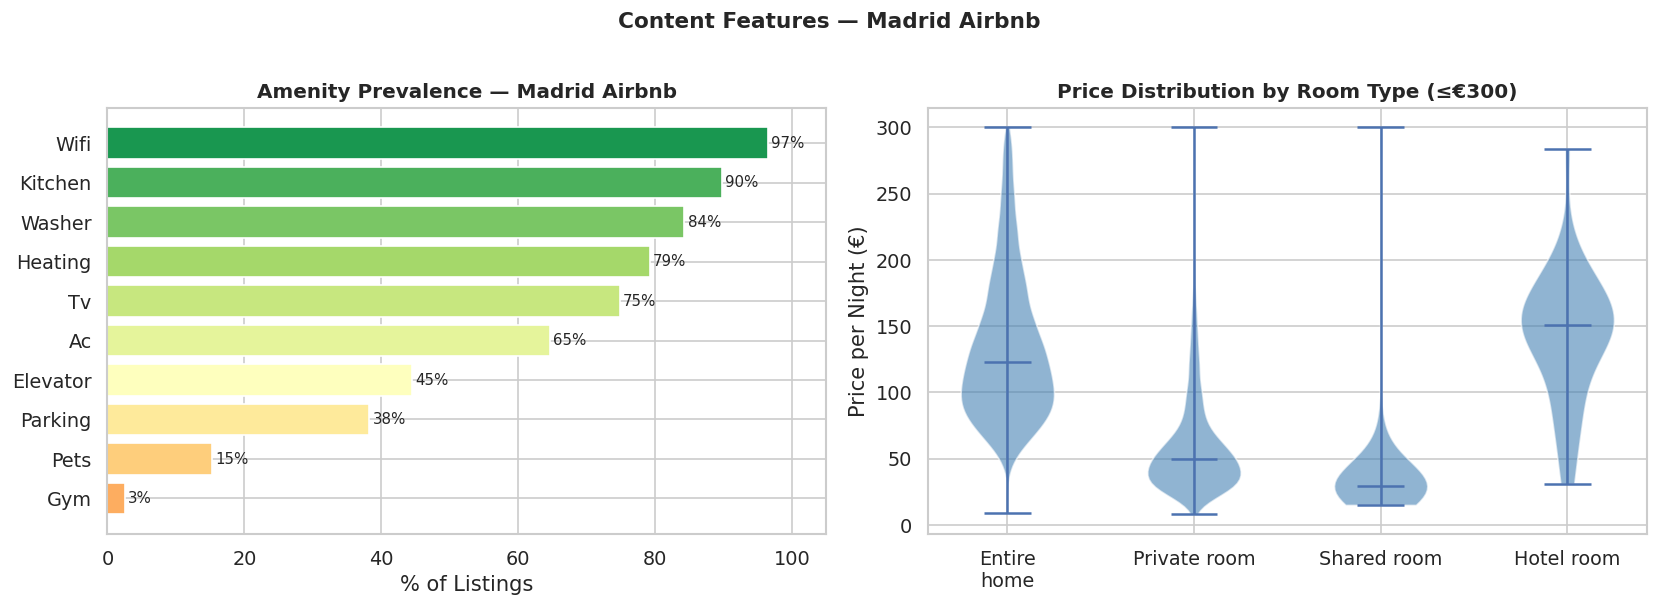

In [10]:
# ── Feature importance visualisation ─────────────────────────────────────────
# Show which feature groups contribute most to similarity variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: amenity prevalence (already computed in nb01 — re-plot here for context)
ax = axes[0]
am_cols  = [c for c in listings.columns if c.startswith('am_')]
am_pct   = listings[am_cols].mean().sort_values() * 100
am_names = [c.replace('am_','').replace('_',' ').title() for c in am_pct.index]
colors_am = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(am_pct)))
bars = ax.barh(am_names, am_pct.values, color=colors_am, edgecolor='white')
for bar, val in zip(bars, am_pct.values):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.0f}%', va='center', fontsize=9)
ax.set_xlim(0, 105)
ax.set_title('Amenity Prevalence — Madrid Airbnb', fontsize=12, fontweight='bold')
ax.set_xlabel('% of Listings')

# Right: price distribution by room type (violin)
ax = axes[1]
plot_data = listings[
    (listings['price_clean'] <= 300) & listings['price_clean'].notna()
].copy()
room_order = ['Entire home/apt','Private room','Shared room','Hotel room']
present_rooms = [r for r in room_order if r in plot_data['room_type'].unique()]

parts = ax.violinplot(
    [plot_data[plot_data['room_type']==rt]['price_clean'].values for rt in present_rooms],
    positions=range(len(present_rooms)), showmedians=True
)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue'); pc.set_alpha(0.6)

ax.set_xticks(range(len(present_rooms)))
ax.set_xticklabels([r.replace(' home/apt','\nhome') for r in present_rooms])
ax.set_ylabel('Price per Night (€)')
ax.set_title('Price Distribution by Room Type (≤€300)', fontsize=12, fontweight='bold')

plt.suptitle('Content Features — Madrid Airbnb', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/03_content_features.png', dpi=150, bbox_inches='tight')
plt.show()

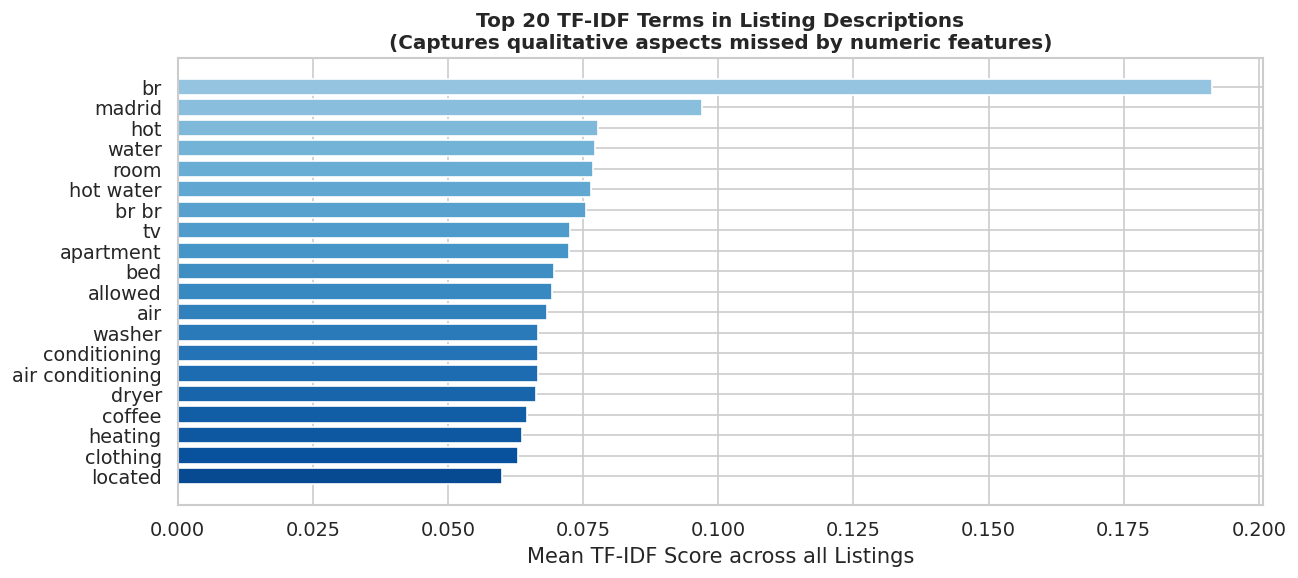

In [11]:
# ── TF-IDF top terms visualisation ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

feature_names  = tfidf.get_feature_names_out()
mean_tfidf     = desc_matrix.mean(axis=0)
top_n          = 20
top_indices    = np.argsort(mean_tfidf)[-top_n:][::-1]
top_terms_list = [feature_names[i] for i in top_indices]
top_vals       = mean_tfidf[top_indices]

colors_tfidf = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))
ax.barh(range(top_n), top_vals[::-1], color=colors_tfidf[::-1], edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_terms_list[::-1])
ax.set_xlabel('Mean TF-IDF Score across all Listings')
ax.set_title('Top 20 TF-IDF Terms in Listing Descriptions\n(Captures qualitative aspects missed by numeric features)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_tfidf_terms.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Evaluation

In [12]:
# ── Ranking evaluation ─────────────────────────
def precision_at_k(rec, rel, k=10):
    return len(set(rec[:k]) & rel) / k
def recall_at_k(rec, rel, k=10):
    return len(set(rec[:k]) & rel) / len(rel) if rel else 0
def ndcg_at_k(rec, rel, k=10):
    dcg  = sum(1/np.log2(i+2) for i, m in enumerate(rec[:k]) if m in rel)
    idcg = sum(1/np.log2(i+2) for i in range(min(k, len(rel))))
    return dcg / idcg if idcg > 0 else 0

# Evaluation: for each query listing, recommend top-10 content-similar listings.
# Relevant = listings in the same neighbourhood with ≥ 4.5 rating (proxy for compatibility).

SPLIT_DATE = pd.Timestamp('2024-07-01')
test_rev = reviews[reviews['date'] >= SPLIT_DATE]
test_listing_ids = test_rev['listing_id'].unique()

np.random.seed(42)
eval_sample = np.random.choice(
    [lid for lid in test_listing_ids if lid in feature_df.index],
    size=min(600, len(test_listing_ids)), replace=False
)

p_scores, r_scores, ndcg_scores, rec_pool = [], [], [], set()

for lid in eval_sample:
    recs_df = recommend_similar_listing(lid, top_k=10)
    if recs_df.empty:
        continue
    recs = recs_df['id'].tolist()

    # Relevant: same neighbourhood, rating >= 4.5, appeared in test set
    hood = listings[listings['id']==lid]['neighbourhood_cleansed'].values
    if len(hood) == 0:
        continue
    relevant = set(
        listings[
            (listings['neighbourhood_cleansed'] == hood[0]) &
            (listings['review_scores_rating'] >= 4.5) &
            (listings['id'].isin(test_listing_ids))
        ]['id']
    ) - {lid}

    if relevant:
        p_scores.append(precision_at_k(recs, relevant))
        r_scores.append(recall_at_k(recs, relevant))
        ndcg_scores.append(ndcg_at_k(recs, relevant))
    rec_pool.update(recs)

# Coverage = fraction of catalog that appears in at least one top-10 recommendation list
coverage = len(rec_pool) / len(listings)

# Map listing IDs to their positions in the feature_matrix for diversity calculation
feat_id_to_pos = {idx: i for i, idx in enumerate(feature_df.index)}

def intra_list_diversity(rec_ids):
    positions = [feat_id_to_pos[rid] for rid in rec_ids if rid in feat_id_to_pos]
    if len(positions) < 2:
        return 0.0
    vecs = feature_matrix[positions]
    sims = cosine_similarity(vecs)
    n = len(positions)
    upper = sims[np.triu_indices(n, k=1)]
    return float(1 - upper.mean())

div_scores = []
for lid in eval_sample:
    recs_df = recommend_similar_listing(lid, top_k=10)
    if not recs_df.empty:
        div_scores.append(intra_list_diversity(recs_df['id'].tolist()))


print(f'Content-Based (Hybrid) ── Evaluation (n={len(p_scores)}):')
print(f'  Precision@10 : {np.mean(p_scores):.4f}')
print(f'  Recall@10    : {np.mean(r_scores):.4f}')
print(f'  NDCG@10      : {np.mean(ndcg_scores):.4f}')
print(f'  Coverage     : {coverage:.4f}  ({coverage*100:.1f}% of catalog)')
print(f'  Diversity    : {np.mean(div_scores):.4f}')

Content-Based (Hybrid) ── Evaluation (n=600):
  Precision@10 : 0.2487
  Recall@10    : 0.0142
  NDCG@10      : 0.2812
  Coverage     : 0.1944  (19.4% of catalog)
  Diversity    : 0.0442


In [13]:
# ── Standardised results table ────────────────────────────────────────────────
results_cb = pd.DataFrame({
    'Approach'    : ['Content-Based (Hybrid: features + TF-IDF)'],
    'RMSE'        : [None],
    'MAE'         : [None],
    'Precision@10': [round(np.mean(p_scores), 4)],
    'Recall@10'   : [round(np.mean(r_scores), 4)],
    'NDCG@10'     : [round(np.mean(ndcg_scores), 4)],
    'Coverage'    : [round(coverage, 4)],
    'Diversity'   : [round(float(np.mean(div_scores)), 4)],
})
print('Content-Based Recommender — Evaluation Results:')
results_cb

Content-Based Recommender — Evaluation Results:


,Approach,RMSE,MAE,Precision@10,Recall@10,NDCG@10,Coverage,Diversity
0,Content-Based (Hybrid: features + TF-IDF),None,None,0.2487,0.0142,0.2812,0.1944,0.0442
